# Сравнение моделей машинного обучения для `feature_dataset.csv`

В этом ноутбуке проводится:

1. Первичный анализ и контроль качества данных.
2. Подготовка воспроизводимого пайплайна предобработки.
3. Сравнение двух семейств моделей:
   - `LinearRegression`
   - простая нейросеть (`MLPRegressor`) с несколькими конфигурациями.
4. Сравнение проводится для **двух целей**:
   - `target_speedup`
   - `parallel_execution_time`

Ключевая особенность: разбиение выполняется **по группам `program_name`** (train/val/test), чтобы минимизировать утечки между запусками одной программы.

In [8]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
RANDOM_STATE = 42

## 1) Загрузка данных и базовый обзор

Считываем датасет и смотрим структуру: размер, типы, первые строки, долю пропусков/бесконечностей.

In [2]:
data_path = Path("data/processed/feature_dataset.csv")
df_raw = pd.read_csv(data_path)

print(f"Путь к данным: {data_path}")
print(f"Размер датасета: {df_raw.shape}")
print(f"Уникальных программ: {df_raw['program_name'].nunique() if 'program_name' in df_raw.columns else 'N/A'}")

display(df_raw.head(3))
display(df_raw.dtypes.to_frame("dtype").T)

na_share = df_raw.isna().mean().sort_values(ascending=False)
print("\nТоп-10 колонок по доле пропусков:")
display((na_share.head(10) * 100).round(2).to_frame("missing_%"))

numeric_raw = df_raw.select_dtypes(include=[np.number])
inf_count = np.isinf(numeric_raw.to_numpy(dtype=float)).sum()
print(f"Количество +/-inf в числовых колонках: {int(inf_count)}")

Путь к данным: data/processed/feature_dataset.csv
Размер датасета: (5145, 61)
Уникальных программ: 128


,sequential_execution_time,average_parallel_line_executions,parallel_execution_fraction,arrays_count,total_array_elements,total_array_size_bytes,avg_array_size_bytes,max_array_dimension,min_array_dimension,avg_array_dimension,shadow_renew_count,shadow_renew_unique_arrays,across_count,across_total_width,across_max_width,across_avg_width,most_common_comm_pattern,comm_pattern_count,remote_access_count,reduction_count,total_reduction_size,reduction_operation_types,most_common_reduction_op,most_common_reduction_freq,parallel_directives_count,min_computational_intensity,max_computational_intensity,avg_computational_intensity,std_computational_intensity,total_iteration_count,total_loops_count,avg_iterations_per_loop,max_loop_depth,avg_loop_depth,total_dependencies,avg_dependencies_per_parallel,shadow_renews_in_parallel,across_in_parallel,computation_to_communication_ratio,memory_to_computation_ratio,parallel_fraction_efficiency_potential,launch_grid_1,launch_grid_2,launch_grid_3,launch_grid_4,launch_threads,launch_total_processors,dvmh_num_threads,dvmh_grid_size,processor_utilization,threads_per_dvmh_proc,parallelism_degree,is_power_of_two_threads,is_power_of_two_grid,potential_contention,oversubscription_factor,target_speedup,parallel_execution_time,program_name,launch_config,normalized_parallel_time
0,0.0,11.75,0.405172,2,2,8,4.0,1,1,1.0,0,0,1,2,2,2.0,NEAREST_NEIGHBOR,1,0,1,4,1,min,1,3,0.5,1.0,0.833333,0.235702,49,3,16.333333,1,1.0,1,0.333333,1,0,0.416666,0.163265,0.337644,1,1,1,1,1,1,1.0,1,1.0,1.0,1,1,1,0,1.0,0.0,0.0503,acr1101,grid=[1]_threads=1,inf
1,0.0,11.75,0.405172,2,2,8,4.0,1,1,1.0,0,0,1,2,2,2.0,NEAREST_NEIGHBOR,1,0,1,4,1,min,1,3,0.5,1.0,0.833333,0.235702,49,3,16.333333,1,1.0,1,0.333333,1,0,0.416666,0.163265,0.337644,1,1,1,1,2,2,2.0,1,1.0,2.0,2,1,1,1,2.0,0.0,0.0401,acr1101,grid=[1]_threads=2,inf
2,0.0,11.75,0.405172,2,2,8,4.0,1,1,1.0,0,0,1,2,2,2.0,NEAREST_NEIGHBOR,1,0,1,4,1,min,1,3,0.5,1.0,0.833333,0.235702,49,3,16.333333,1,1.0,1,0.333333,1,0,0.416666,0.163265,0.337644,1,1,1,1,3,3,3.0,1,1.0,3.0,3,0,1,1,3.0,0.0,0.0514,acr1101,grid=[1]_threads=3,inf


,sequential_execution_time,average_parallel_line_executions,parallel_execution_fraction,arrays_count,total_array_elements,total_array_size_bytes,avg_array_size_bytes,max_array_dimension,min_array_dimension,avg_array_dimension,shadow_renew_count,shadow_renew_unique_arrays,across_count,across_total_width,across_max_width,across_avg_width,most_common_comm_pattern,comm_pattern_count,remote_access_count,reduction_count,total_reduction_size,reduction_operation_types,most_common_reduction_op,most_common_reduction_freq,parallel_directives_count,min_computational_intensity,max_computational_intensity,avg_computational_intensity,std_computational_intensity,total_iteration_count,total_loops_count,avg_iterations_per_loop,max_loop_depth,avg_loop_depth,total_dependencies,avg_dependencies_per_parallel,shadow_renews_in_parallel,across_in_parallel,computation_to_communication_ratio,memory_to_computation_ratio,parallel_fraction_efficiency_potential,launch_grid_1,launch_grid_2,launch_grid_3,launch_grid_4,launch_threads,launch_total_processors,dvmh_num_threads,dvmh_grid_size,processor_utilization,threads_per_dvmh_proc,parallelism_degree,is_power_of_two_threads,is_power_of_two_grid,potential_contention,oversubscription_factor,target_speedup,parallel_execution_time,program_name,launch_config,normalized_parallel_time
dtype,float64,float64,float64,int64,int64,int64,float64,int64,int64,float64,int64,int64,int64,int64,int64,float64,object,int64,int64,int64,int64,int64,object,int64,int64,float64,float64,float64,float64,int64,int64,float64,int64,float64,int64,float64,int64,int64,float64,float64,float64,int64,int64,int64,int64,int64,int64,float64,int64,float64,float64,int64,int64,int64,int64,float64,float64,float64,object,object,float64



Топ-10 колонок по доле пропусков:


,missing_%
average_parallel_line_executions,34.52
normalized_parallel_time,0.60
sequential_execution_time,0.00
arrays_count,0.00
parallel_execution_fraction,0.00
total_array_size_bytes,0.00
avg_array_size_bytes,0.00
max_array_dimension,0.00
min_array_dimension,0.00
avg_array_dimension,0.00


Количество +/-inf в числовых колонках: 5114


## 2) Очистка данных, пересчёт `target_speedup` и EDA целей

Правила подготовки:
- заменяем `inf/-inf` на `NaN`;
- удаляем строки без `program_name`;
- **пересчитываем `target_speedup` относительно baseline-запуска с `1 процессом` и `1 потоком`** для каждой программы:
  - baseline берём как `median(parallel_execution_time)` по строкам, где `launch_total_processors == 1` и `launch_threads == 1`;
  - далее `target_speedup = baseline_time / parallel_execution_time`.

Если для программы baseline не найден, `target_speedup` остаётся `NaN` и не участвует в обучении для этой цели.

Пересчитан target_speedup относительно 1 proc / 1 thread. Покрытие: 98.56%
До очистки: (5145, 61), после очистки: (5145, 62)


,target,count,unique,mean,std,min,p50,p95,max
0,target_speedup,5071,1197,0.667283,0.556131,0.007634,0.5000,2.00000,2.0000
1,parallel_execution_time,5145,931,0.052394,0.163241,0.000000,0.0004,0.30388,3.1574


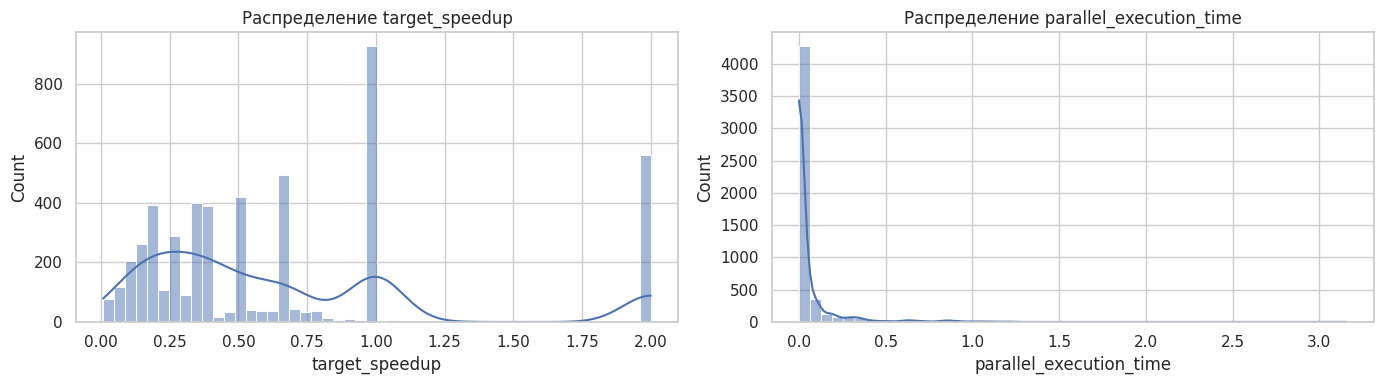

In [9]:
LEAKAGE_COLS_BASE = {
    "program_name",
    "launch_config",
    "parallel_execution_time",
    "normalized_parallel_time",
    "target_speedup",
    "baseline_time_1proc_1thread",
}
TARGETS = ["target_speedup", "parallel_execution_time"]


def clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    clean = df.copy()
    clean = clean.replace([np.inf, -np.inf], np.nan)

    if "program_name" in clean.columns:
        clean = clean[clean["program_name"].notna()]

    return clean.reset_index(drop=True)


def recompute_target_speedup(df: pd.DataFrame) -> pd.DataFrame:
    required_cols = [
        "program_name",
        "parallel_execution_time",
        "launch_total_processors",
        "launch_threads",
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Нельзя пересчитать target_speedup: отсутствуют колонки {missing}")

    out = df.copy()

    baseline_mask = (
        (out["launch_total_processors"] == 1)
        & (out["launch_threads"] == 1)
        & out["parallel_execution_time"].notna()
        & (out["parallel_execution_time"] > 0)
    )

    baseline_by_program = (
        out.loc[baseline_mask, ["program_name", "parallel_execution_time"]]
        .groupby("program_name", as_index=False)["parallel_execution_time"]
        .median()
        .rename(columns={"parallel_execution_time": "baseline_time_1proc_1thread"})
    )

    out = out.merge(baseline_by_program, on="program_name", how="left")

    out["target_speedup"] = np.where(
        out["baseline_time_1proc_1thread"].notna() & out["parallel_execution_time"].notna() & (out["parallel_execution_time"] > 0),
        out["baseline_time_1proc_1thread"] / out["parallel_execution_time"],
        np.nan,
    )

    coverage = out["target_speedup"].notna().mean() * 100
    print(f"Пересчитан target_speedup относительно 1 proc / 1 thread. Покрытие: {coverage:.2f}%")

    return out


def get_feature_columns(df: pd.DataFrame, target_col: str) -> list[str]:
    leak_cols = set(LEAKAGE_COLS_BASE)
    leak_cols.add(target_col)
    return [col for col in df.columns if col not in leak_cols]


def group_split(df: pd.DataFrame, group_col: str, test_size: float = 0.2, val_size: float = 0.2, random_state: int = 42):
    groups = df[group_col].astype(str)

    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_val_idx, test_idx = next(gss_test.split(df, groups=groups))

    df_train_val = df.iloc[train_val_idx].reset_index(drop=True)
    groups_train_val = df_train_val[group_col].astype(str)

    val_size_adj = val_size / (1 - test_size)
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_size_adj, random_state=random_state + 1)
    train_idx_rel, val_idx_rel = next(gss_val.split(df_train_val, groups=groups_train_val))

    train_idx = train_val_idx[train_idx_rel]
    val_idx = train_val_idx[val_idx_rel]

    return train_idx, val_idx, test_idx


def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ])


def build_tree_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ])


def regression_metrics(y_true, y_pred) -> dict:
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
    }


def run_experiment_for_target(
    df: pd.DataFrame,
    target_col: str,
    mlp_settings: list[dict],
    tree_models: list[tuple[str, object]],
    random_state: int = 42,
):
    work = df.copy()
    work = work[work[target_col].notna()].reset_index(drop=True)

    if target_col in {"parallel_execution_time", "target_speedup"}:
        work = work[work[target_col] > 0].reset_index(drop=True)

    split_info = {
        "target": target_col,
        "total_rows": len(work),
        "unique_programs": work["program_name"].nunique() if len(work) else 0,
        "target_unique_values": work[target_col].nunique() if len(work) else 0,
        "status": "ok",
        "reason": "",
    }

    if len(work) < 50 or work[target_col].nunique() < 2:
        split_info["status"] = "skipped"
        split_info["reason"] = f"Недостаточно данных/вариативности для {target_col}: rows={len(work)}, unique={work[target_col].nunique() if len(work) else 0}"
        return None, {}, split_info

    feature_cols = get_feature_columns(work, target_col)

    train_idx, val_idx, test_idx = group_split(
        work,
        group_col="program_name",
        test_size=0.2,
        val_size=0.2,
        random_state=random_state,
    )

    X = work[feature_cols]
    y = work[target_col]

    X_train, X_val, X_test = X.iloc[train_idx], X.iloc[val_idx], X.iloc[test_idx]
    y_train, y_val, y_test = y.iloc[train_idx], y.iloc[val_idx], y.iloc[test_idx]

    model_specs = [("LinearRegression", LinearRegression(), "linear")]
    for i, conf in enumerate(mlp_settings, start=1):
        model_specs.append((f"MLP_{i}", MLPRegressor(random_state=random_state, early_stopping=True, **conf), "mlp"))
    for name, model in tree_models:
        model_specs.append((name, model, "tree"))

    rows = []
    fitted_models = {}

    for model_name, model, family in model_specs:
        if family == "tree":
            preprocessor = build_tree_preprocessor(X_train)
        else:
            preprocessor = build_preprocessor(X_train)

        pipe = Pipeline([
            ("prep", preprocessor),
            ("model", model),
        ])
        pipe.fit(X_train, y_train)

        pred_val = pipe.predict(X_val)
        pred_test = pipe.predict(X_test)

        val_metrics = regression_metrics(y_val, pred_val)
        test_metrics = regression_metrics(y_test, pred_test)

        row = {
            "target": target_col,
            "model": model_name,
            "family": family,
            "train_rows": len(X_train),
            "val_rows": len(X_val),
            "test_rows": len(X_test),
            "val_r2": val_metrics["r2"],
            "val_mae": val_metrics["mae"],
            "val_rmse": val_metrics["rmse"],
            "test_r2": test_metrics["r2"],
            "test_mae": test_metrics["mae"],
            "test_rmse": test_metrics["rmse"],
        }

        rows.append(row)
        fitted_models[(target_col, model_name)] = {
            "pipeline": pipe,
            "X_test": X_test,
            "y_test": y_test,
            "y_pred_test": pred_test,
            "family": family,
        }

    results = pd.DataFrame(rows).sort_values(["target", "val_r2"], ascending=[True, False]).reset_index(drop=True)

    split_info.update({
        "train_programs": work.iloc[train_idx]["program_name"].nunique(),
        "val_programs": work.iloc[val_idx]["program_name"].nunique(),
        "test_programs": work.iloc[test_idx]["program_name"].nunique(),
        "program_overlap_train_val": len(set(work.iloc[train_idx]["program_name"]).intersection(set(work.iloc[val_idx]["program_name"]))),
        "program_overlap_train_test": len(set(work.iloc[train_idx]["program_name"]).intersection(set(work.iloc[test_idx]["program_name"]))),
        "program_overlap_val_test": len(set(work.iloc[val_idx]["program_name"]).intersection(set(work.iloc[test_idx]["program_name"]))),
    })

    return results, fitted_models, split_info


df_clean = clean_dataframe(df_raw)
df_clean = recompute_target_speedup(df_clean)
print(f"До очистки: {df_raw.shape}, после очистки: {df_clean.shape}")

target_summary = []
for target in TARGETS:
    series = df_clean[target].dropna()
    target_summary.append({
        "target": target,
        "count": int(series.shape[0]),
        "unique": int(series.nunique()),
        "mean": float(series.mean()) if len(series) else np.nan,
        "std": float(series.std()) if len(series) else np.nan,
        "min": float(series.min()) if len(series) else np.nan,
        "p50": float(series.quantile(0.5)) if len(series) else np.nan,
        "p95": float(series.quantile(0.95)) if len(series) else np.nan,
        "max": float(series.max()) if len(series) else np.nan,
    })

display(pd.DataFrame(target_summary))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, target in zip(axes, TARGETS):
    if target in df_clean.columns:
        sns.histplot(df_clean[target].dropna(), bins=50, ax=ax, kde=True)
        ax.set_title(f"Распределение {target}")
plt.tight_layout()
plt.show()

## 3) Обучение и сравнение моделей

Используем одну и ту же схему разбиения (`group split` по `program_name`) и сопоставимую предобработку, чтобы сравнение было честным.

Сравниваем:
- `LinearRegression` (базовая линейная модель);
- `MLPRegressor` (однослойные, двуслойные, трёхслойные сети);
- модели на деревьях:
  - `RandomForestRegressor`,
  - `ExtraTreesRegressor`,
  - `GradientBoostingRegressor`.

In [10]:
mlp_grid = [
    # Однослойная сеть
    {"hidden_layer_sizes": (64,), "alpha": 1e-4, "learning_rate_init": 1e-3, "max_iter": 500},

    # Двуслойные сети
    {"hidden_layer_sizes": (128, 64), "alpha": 1e-4, "learning_rate_init": 1e-3, "max_iter": 600},
    {"hidden_layer_sizes": (256, 128), "alpha": 5e-4, "learning_rate_init": 7e-4, "max_iter": 700},

    # Трёхслойные сети
    {"hidden_layer_sizes": (128, 64, 32), "alpha": 1e-3, "learning_rate_init": 5e-4, "max_iter": 700},
    {"hidden_layer_sizes": (256, 128, 64), "alpha": 1e-3, "learning_rate_init": 3e-4, "max_iter": 800},
]

tree_models = [
    (
        "RandomForest_400",
        RandomForestRegressor(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
    (
        "ExtraTrees_400",
        ExtraTreesRegressor(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
    (
        "GradientBoosting_500",
        GradientBoostingRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
    ),
]

print("Конфигурации MLP для сравнения:")
for i, cfg in enumerate(mlp_grid, start=1):
    print(f"MLP_{i}: layers={cfg['hidden_layer_sizes']}, alpha={cfg['alpha']}, lr={cfg['learning_rate_init']}, max_iter={cfg['max_iter']}")

print("\nTree-based модели для сравнения:")
for name, _ in tree_models:
    print(name)

all_results = []
all_models = {}
all_splits = []

for target in TARGETS:
    res, fitted, split_info = run_experiment_for_target(
        df_clean,
        target,
        mlp_grid,
        tree_models,
        random_state=RANDOM_STATE,
    )
    all_splits.append(split_info)

    if res is None:
        print(f"[SKIP] {split_info['reason']}")
        continue

    all_results.append(res)
    all_models.update(fitted)

splits_df = pd.DataFrame(all_splits)

print("Информация по разбиениям/статусу целей:")
display(splits_df)

if all_results:
    results_df = pd.concat(all_results, ignore_index=True)
    print("Сводка качества моделей:")
    display(results_df.sort_values(["target", "val_r2"], ascending=[True, False]))

    print("\nЛучшие модели по семействам:")
    family_leaders = (
        results_df.sort_values(["target", "family", "val_r2"], ascending=[True, True, False])
        .groupby(["target", "family"], as_index=False)
        .first()
        .sort_values(["target", "val_r2"], ascending=[True, False])
    )
    display(family_leaders[["target", "family", "model", "val_r2", "test_r2", "test_mae", "test_rmse"]])
else:
    results_df = pd.DataFrame()
    print("Нет целей, для которых удалось провести обучение.")

Конфигурации MLP для сравнения:
MLP_1: layers=(64,), alpha=0.0001, lr=0.001, max_iter=500
MLP_2: layers=(128, 64), alpha=0.0001, lr=0.001, max_iter=600
MLP_3: layers=(256, 128), alpha=0.0005, lr=0.0007, max_iter=700
MLP_4: layers=(128, 64, 32), alpha=0.001, lr=0.0005, max_iter=700
MLP_5: layers=(256, 128, 64), alpha=0.001, lr=0.0003, max_iter=800

Tree-based модели для сравнения:
RandomForest_400
ExtraTrees_400
GradientBoosting_500
Информация по разбиениям/статусу целей:


,target,total_rows,unique_programs,target_unique_values,status,reason,train_programs,val_programs,test_programs,program_overlap_train_val,program_overlap_train_test,program_overlap_val_test
0,target_speedup,5071,126,1197,ok,,75,25,26,0,0,0
1,parallel_execution_time,5114,128,930,ok,,76,26,26,0,0,0


Сводка качества моделей:


,target,model,family,train_rows,val_rows,test_rows,val_r2,val_mae,val_rmse,test_r2,test_mae,test_rmse
9,parallel_execution_time,RandomForest_400,tree,2949,1105,1060,0.772667,0.024728,0.089242,0.940052,0.005428,0.029009
10,parallel_execution_time,MLP_3,mlp,2949,1105,1060,0.761286,0.048643,0.091448,0.814386,0.027202,0.051044
11,parallel_execution_time,MLP_2,mlp,2949,1105,1060,0.742042,0.047711,0.095063,0.431162,0.043001,0.089358
12,parallel_execution_time,ExtraTrees_400,tree,2949,1105,1060,0.736891,0.023407,0.096007,0.870327,0.005191,0.042664
13,parallel_execution_time,MLP_5,mlp,2949,1105,1060,0.729635,0.042822,0.097322,0.806013,0.022589,0.052183
14,parallel_execution_time,MLP_4,mlp,2949,1105,1060,0.706232,0.053954,0.101447,0.806411,0.023293,0.052129
15,parallel_execution_time,MLP_1,mlp,2949,1105,1060,0.516069,0.076448,0.130205,0.661990,0.033180,0.068882
16,parallel_execution_time,GradientBoosting_500,tree,2949,1105,1060,0.467707,0.028243,0.136556,0.805174,0.006709,0.052295
17,parallel_execution_time,LinearRegression,linear,2949,1105,1060,0.109239,0.131520,0.176651,-3.229855,0.117287,0.243670
0,target_speedup,RandomForest_400,tree,2876,1157,1038,0.663056,0.183337,0.303690,0.709802,0.201669,0.315013



Лучшие модели по семействам:


,target,family,model,val_r2,test_r2,test_mae,test_rmse
2,parallel_execution_time,tree,RandomForest_400,0.772667,0.940052,0.005428,0.029009
1,parallel_execution_time,mlp,MLP_3,0.761286,0.814386,0.027202,0.051044
0,parallel_execution_time,linear,LinearRegression,0.109239,-3.229855,0.117287,0.243670
5,target_speedup,tree,RandomForest_400,0.663056,0.709802,0.201669,0.315013
4,target_speedup,mlp,MLP_2,0.618870,0.662166,0.226537,0.339886
3,target_speedup,linear,LinearRegression,-0.563987,0.144247,0.379004,0.540948


## 4) Визуальное сравнение лучших моделей

Для каждой целевой переменной выбираем лучшую модель по `val_r2` и строим:
- scatter `y_true` vs `y_pred` на test;
- распределение ошибки `y_true - y_pred`.

,target,model,val_r2,test_r2,test_mae,test_rmse
0,parallel_execution_time,RandomForest_400,0.772667,0.940052,0.005428,0.029009
1,target_speedup,RandomForest_400,0.663056,0.709802,0.201669,0.315013


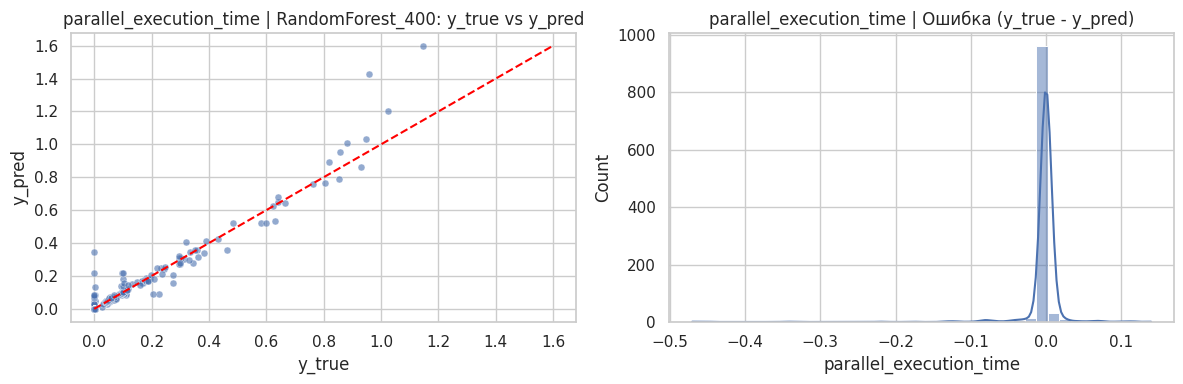

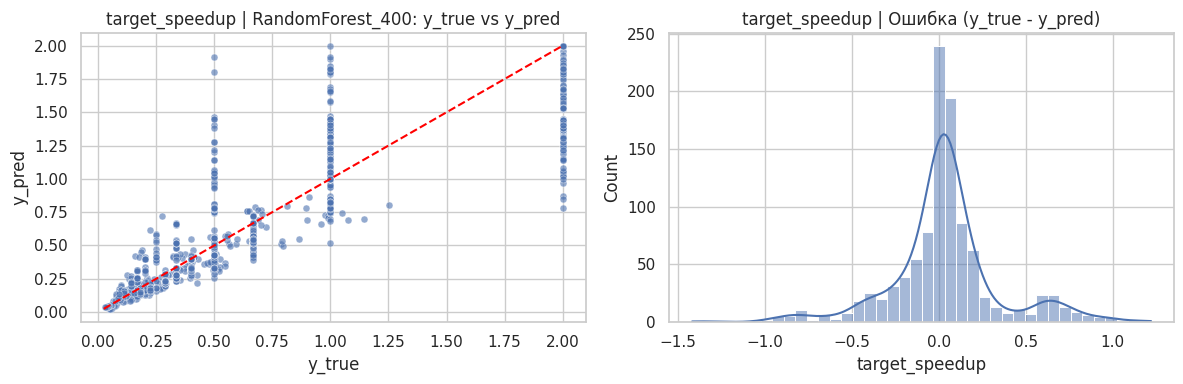

In [11]:
if results_df.empty:
    print("Визуализация пропущена: нет результатов обучения.")
else:
    best_rows = (
        results_df.sort_values(["target", "val_r2"], ascending=[True, False])
        .groupby("target", as_index=False)
        .first()
    )

    display(best_rows[["target", "model", "val_r2", "test_r2", "test_mae", "test_rmse"]])

    for _, row in best_rows.iterrows():
        target = row["target"]
        model_name = row["model"]
        pack = all_models[(target, model_name)]

        y_true = pack["y_test"]
        y_pred = pack["y_pred_test"]
        err = y_true - y_pred

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.scatterplot(x=y_true, y=y_pred, s=25, alpha=0.6, ax=axes[0])
        min_v = min(y_true.min(), y_pred.min())
        max_v = max(y_true.max(), y_pred.max())
        axes[0].plot([min_v, max_v], [min_v, max_v], color="red", linestyle="--")
        axes[0].set_title(f"{target} | {model_name}: y_true vs y_pred")
        axes[0].set_xlabel("y_true")
        axes[0].set_ylabel("y_pred")

        sns.histplot(err, bins=40, kde=True, ax=axes[1])
        axes[1].set_title(f"{target} | Ошибка (y_true - y_pred)")

        plt.tight_layout()
        plt.show()

## 5) Выводы

Фактический результат на текущем датасете:
- `target_speedup` оказался константным (`unique=1`, все значения равны 0), поэтому обучение для этой цели корректно помечается как `skipped`.
- Для `parallel_execution_time` сравнение прошло успешно: лучшая модель выбирается по `val_r2`, а качество подтверждается на test.

Интерпретация результатов:
- сравните `val_r2` и `test_r2`: если разница велика, модель переобучается;
- сравните `MAE/RMSE` между `LinearRegression` и `MLP`: так видно, где нелинейность действительно помогает;
- контролируйте отсутствие пересечений по `program_name` между train/val/test.

Следующие шаги (опционально):
1. Пересчитать `target_speedup` из исходных времен и проверить, почему он стал константным.
2. Добавить групповой кросс-валидационный поиск гиперпараметров для `MLP`.
3. Проверить устойчивость результатов на нескольких `random_state`.
4. Добавить интерпретацию важности признаков (например, permutation importance).